In [21]:
import numpy as np
import torch
import json

from data.dataset import LandmarksDataset, ToTensor, ToTensorWithSeg
from data.transforms import Scale
from models.hybridgnet_se_resnext_dual import HybridDual
from models.hybridgnet_se_resnext import Hybrid
from models.utils import load_config
from torchvision import transforms

Load model, configs and import test dataset

In [22]:
DATASET = '../Dataset/Sunnybrook/Landmarks_3_10'
NAME = 'Sunnybrook_dual_3'

hyperparameters = json.load(open("../Trained/SunnyBrook/%s/hyperparameters.json"%NAME))

config, D_t, U_t, A_t = load_config(DATASET, hyperparameters)
config['resume'] = "../Trained/SunnyBrook/%s/%s.pth"%(NAME, NAME)
config['raster_as_input'] = False

if not config['use_dual']:
    model = Hybrid(config, D_t, U_t, A_t).to(config['device'])
else:
    model = HybridDual(config, D_t, U_t, A_t).to(config['device'])
    
print("Image Encoder filters", model.encoder.filters + [model.encoder.filters[-1]])
print("Bottleneck latents", model.encoder.latents)
print("Graph convolutional filters", config['filters'][::-1])

if config['resume']:
    model.load_checkpoint(config['resume'], config['device'])
    
images = np.loadtxt("%s/test.txt"%DATASET, dtype = str)
val_dataset = LandmarksDataset(images, "%s/images"%DATASET, "%s/landmarks"%DATASET, 
                               transform = transforms.Compose([Scale(config['inputsize']), ToTensorWithSeg()]))

Loading adjacency matrices ../Dataset/Sunnybrook/Landmarks_3_10/Naive/adj_full_block_diagonal.npy
Image Encoder filters [16, 32, 64, 128, 256, 256]
Bottleneck latents 64
Graph convolutional filters [32, 32, 24, 24, 16, 16, 8, 2]


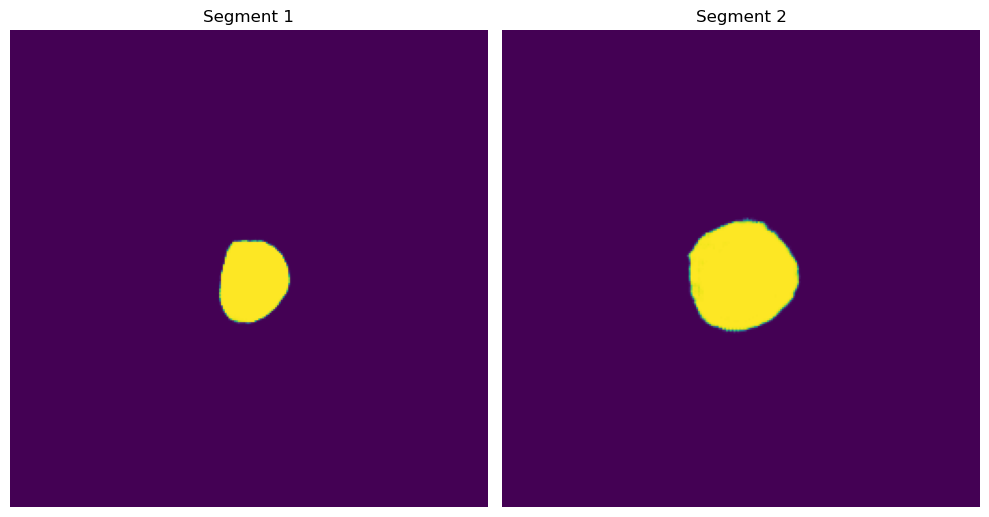

In [23]:
import matplotlib.pyplot as plt

if config['use_dual']:
    sample1 = val_dataset[10]
    out1, _, seg = model(sample1['image'].unsqueeze(0).to(config['device']))

    seg = seg.squeeze().detach().cpu().numpy()

    subplots = len(seg)

    plt.figure(figsize=(10,10))
    for i in range(subplots):
        plt.subplot(1, subplots, i + 1)
        plt.imshow(seg[i])
        plt.axis('off')
        plt.title("Segment %d" % (i + 1))
    plt.tight_layout()

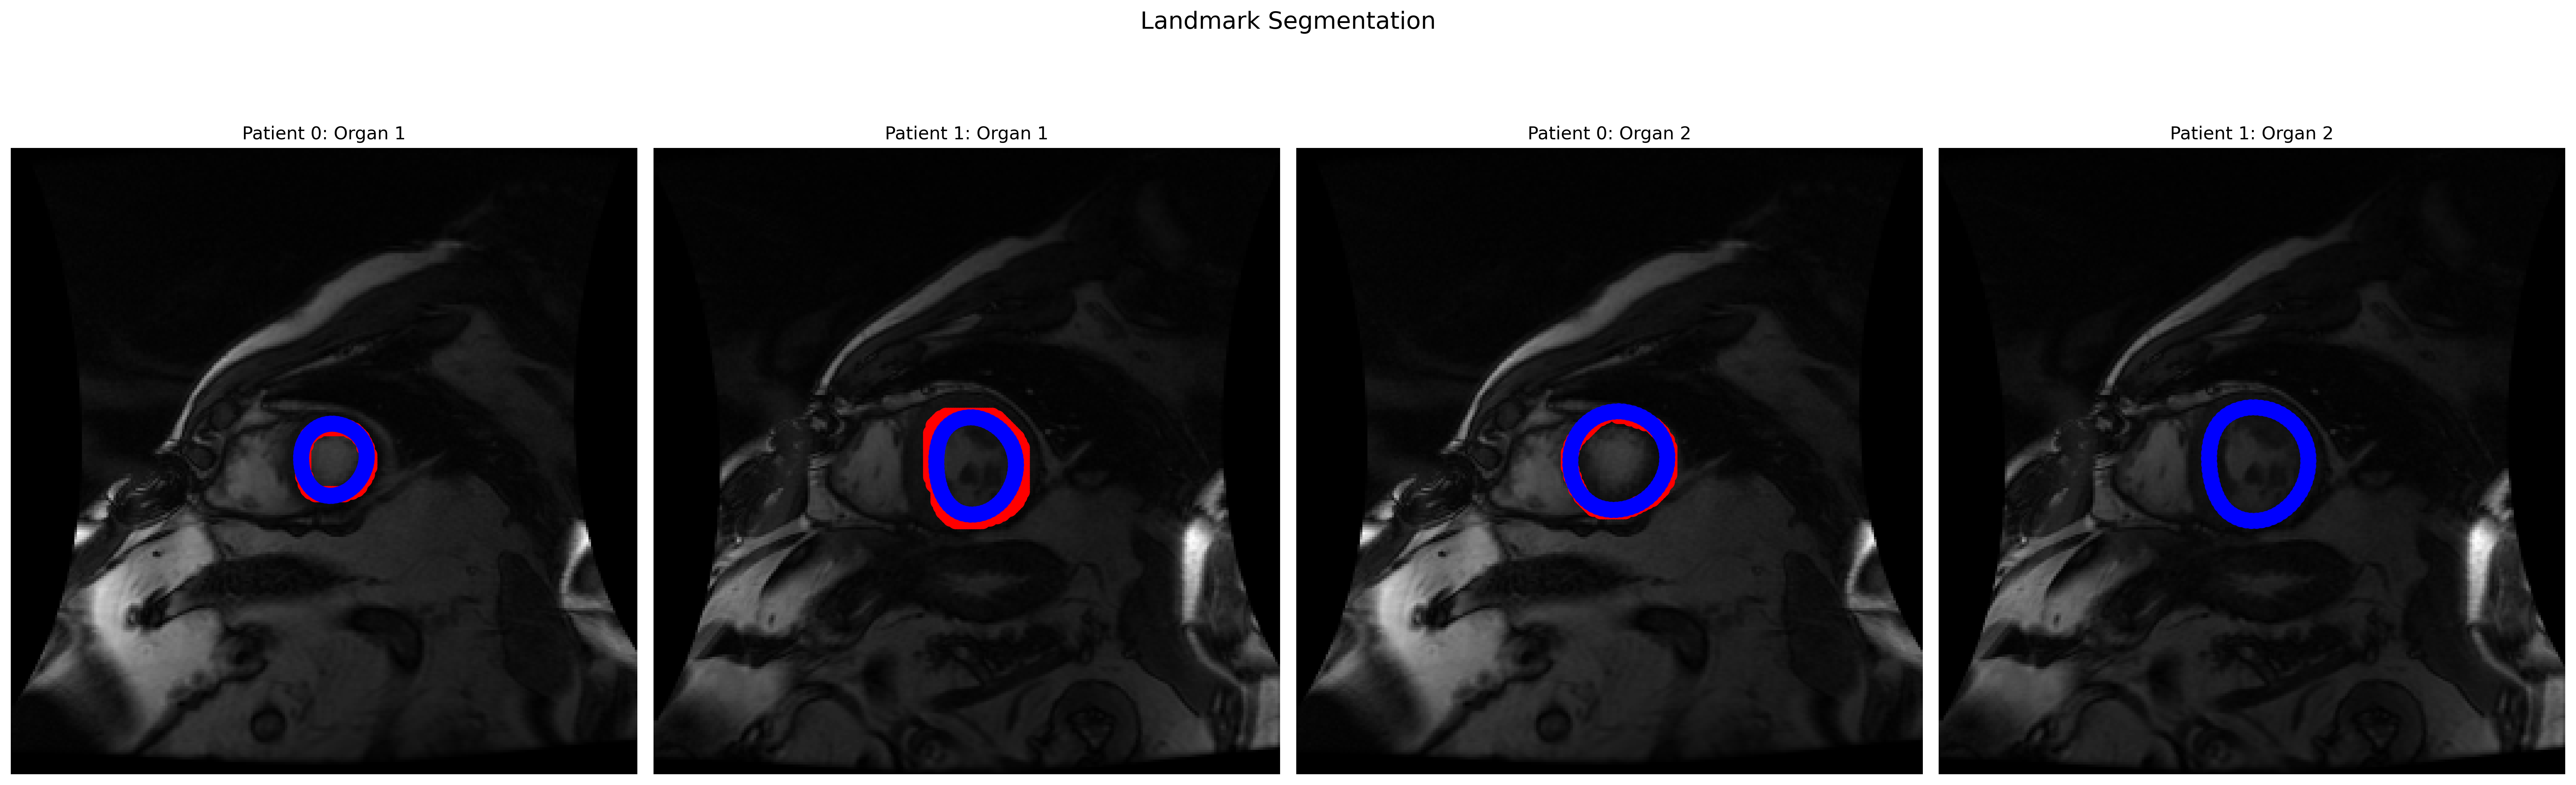

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import random
from utils.image_processing import draw_lines, draw_organ

# Load organ IDs
organ_id = np.load("%s/Naive/adj_full_organ_id.npy" % DATASET)[:,0]
organ_order = np.unique(organ_id)

# Enable interactive mode
plt.ion()

# Create a figure with appropriate size
plt.figure(figsize=(24, 8), dpi=300)

# Number of sample pairs to display
num_samples = 1

# Randomly select indices from the validation set
random_indices = random.sample(range(len(val_dataset)), num_samples * 2)
# Split indices into two groups for side-by-side comparison
comparison_pairs = [(random_indices[i], random_indices[i+num_samples]) for i in range(num_samples)]

comparison_pairs = [[0, 1]]

# For each randomly selected pair of samples
for j, (idx1, idx2) in enumerate(comparison_pairs):
    # Get the two samples from validation set
    sample1 = val_dataset[idx1]
    image1, landmarks1, raster1 = sample1['image'], sample1['landmarks'], sample1['raster']
    
    sample2 = val_dataset[idx2]
    image2, landmarks2, raster2 = sample2['image'], sample2['landmarks'], sample2['raster']
    
    # Run model inference
    out1 = model(image1.unsqueeze(0).to(config['device']))[0]
    out1 = out1 * config['inputsize']
    output1 = out1.squeeze(0).cpu().detach().numpy()
    
    out2 = model(image2.unsqueeze(0).to(config['device']))[0]
    out2 = out2 * config['inputsize']
    output2 = out2.squeeze(0).cpu().detach().numpy()
    
    # Convert tensors to numpy arrays
    img1 = image1.squeeze(0).cpu().detach().numpy()
    img2 = image2.squeeze(0).cpu().detach().numpy()
    
    # Get organ labels
    organs1 = landmarks1[:, 2].cpu().numpy()
    organs2 = landmarks2[:, 2].cpu().numpy()
    
    # Plot each organ
    i = 1
    for organ in np.unique(organ_id):
        # Skip if this organ doesn't exist in both samples
        #if organ not in organs1 or organ not in organs2:
        #    continue
            
        # Get indices for this organ
        idx_organ = organ_id == organ
        idx_target1 = organs1 == organ
        idx_target2 = organs2 == organ
        
        # Plot first sample
        ax1 = plt.subplot(num_samples, 4, i + j*10)
        plt.imshow(img1, cmap='gray')
        target1 = landmarks1[idx_target1, :2]
        target1 = target1 * config['inputsize']
        
        # Draw ground truth and predictions
        draw_organ(ax1, target1, 'r', 3)
        draw_lines(ax1, output1[idx_organ])
        draw_organ(ax1, output1[idx_organ], radius = 3)
        plt.title(f"Patient {idx1}: Organ {int(organ)}")
        plt.axis('off')
        
        # Plot second sample (side by side)
        ax2 = plt.subplot(num_samples, 4, i+1 + j*10)
        plt.imshow(img2, cmap='gray')
        target2 = landmarks2[idx_target2, :2]
        target2 = target2 * config['inputsize']
        
        # Draw ground truth and predictions
        draw_organ(ax2, target2, 'r', 3)
        draw_lines(ax2, output2[idx_organ])
        draw_organ(ax2, output2[idx_organ], radius = 3)
        plt.title(f"Patient {idx2}: Organ {int(organ)}")
        plt.axis('off')
        
        i += 2
        
        # If we've shown 3 organs, move to next row
        #if i > 5:
        #    break

# Add a title for the entire figure
plt.suptitle("Landmark Segmentation", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for suptitle

plt.show()

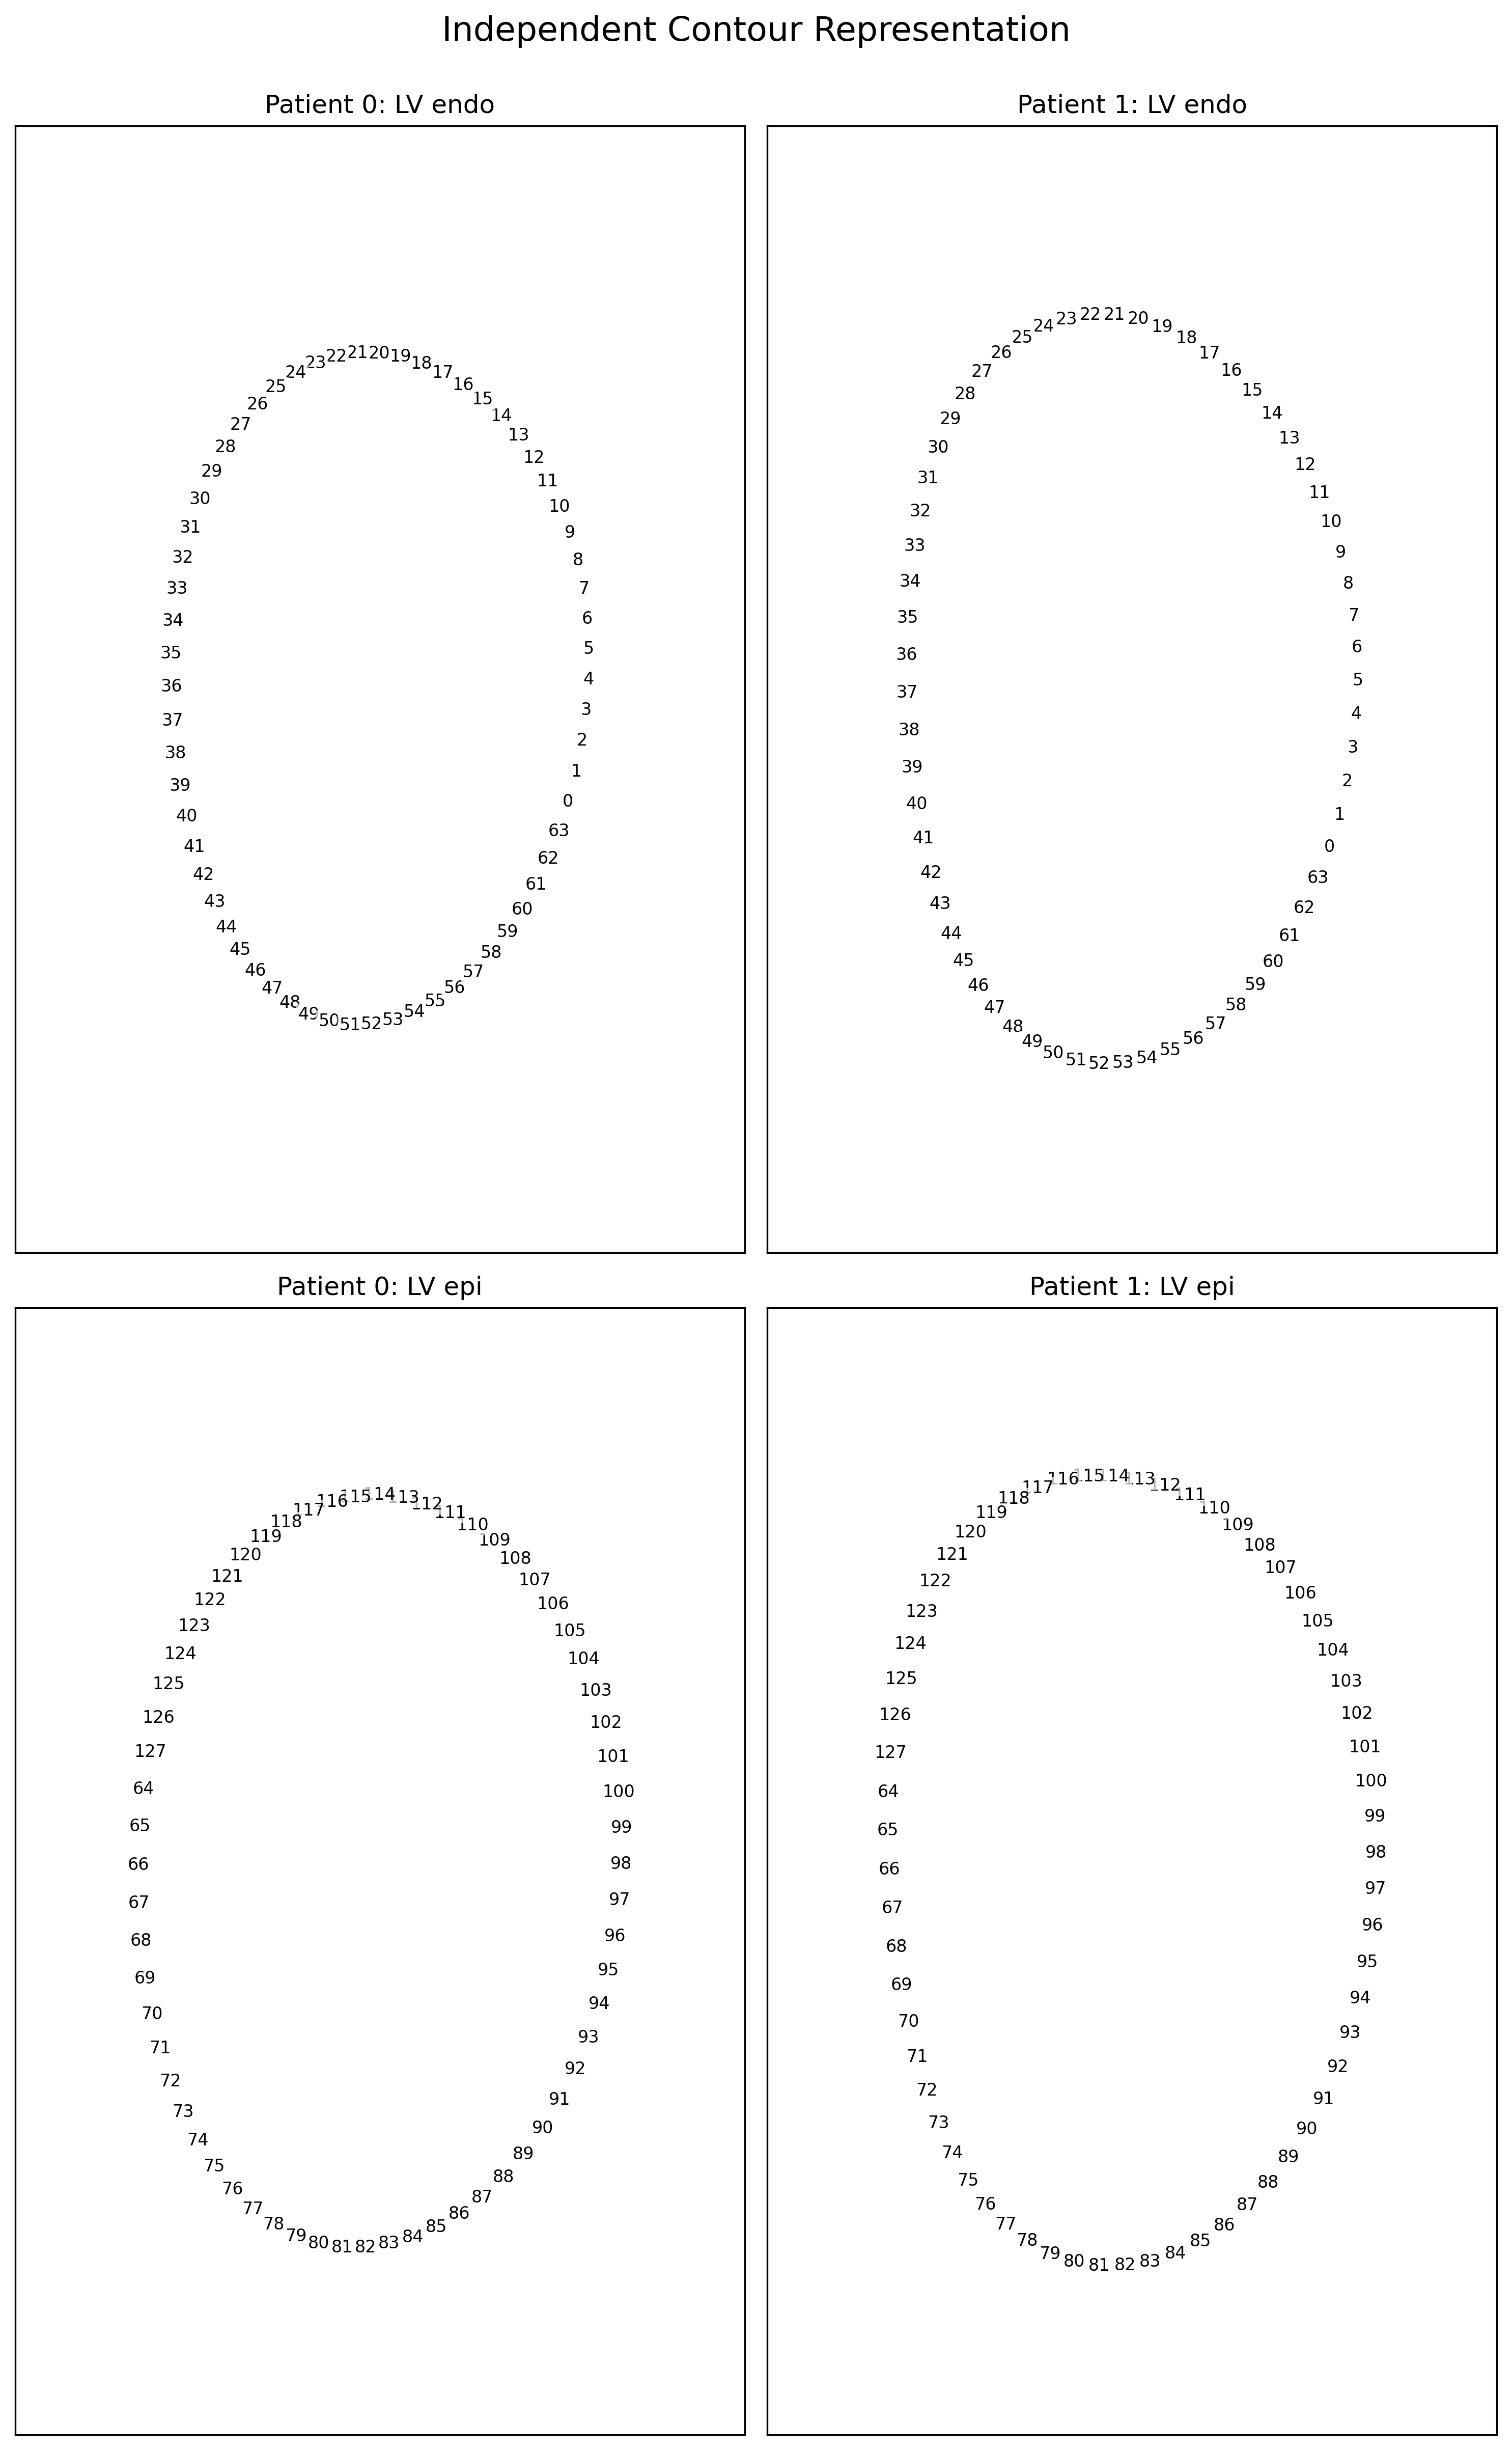

In [25]:
# Create a second figure for numbered landmarks without background
plt.figure(figsize=(10, 40), dpi=300)

# For each randomly selected pair of samples again
for j, (idx1, idx2) in enumerate(comparison_pairs):
    # Get the two samples from validation set
    sample1 = val_dataset[idx1]
    landmarks1 = sample1['landmarks']
    
    sample2 = val_dataset[idx2]
    landmarks2 = sample2['landmarks']
    
    # Run model inference to get predictions
    out1 = model(sample1['image'].unsqueeze(0).to(config['device']))[0]
    out1 = out1 * config['inputsize']
    output1 = out1.squeeze(0).cpu().detach().numpy()
    
    out2 = model(sample2['image'].unsqueeze(0).to(config['device']))[0]
    out2 = out2 * config['inputsize']
    output2 = out2.squeeze(0).cpu().detach().numpy()
    
    # Get organ labels
    organs1 = landmarks1[:, 2].cpu().numpy()
    organs2 = landmarks2[:, 2].cpu().numpy()
    
    # Plot each organ
    i = 1
    for organ in np.unique(organ_id):            
        # Get indices for this organ
        idx_organ = organ_id == organ
        idx_target1 = organs1 == organ
        idx_target2 = organs2 == organ
        
        # Get predicted landmark points
        pred1 = output1[idx_organ]
        pred2 = output2[idx_organ]
        
        # Create blank white background for first patient
        ax1 = plt.subplot(5, 2, i + j*10)
        ax1.set_facecolor('white')
        
        # Set appropriate axis limits based only on prediction coordinates
        max_x = np.max(pred1[:, 0])
        max_y = np.max(pred1[:, 1])
        min_x = np.min(pred1[:, 0])
        min_y = np.min(pred1[:, 1])
        
        # Add some padding
        padding = 10
        ax1.set_xlim(min_x - padding, max_x + padding)
        ax1.set_ylim(max_y + padding, min_y - padding)  # Inverted y-axis for image coordinates
        
        # Draw lines between landmarks
        # draw_lines(ax1, pred1, color='b')
        
        # Number each landmark
        k = 0
        for _, (x, y) in enumerate(pred1):
            while idx_organ[k] == False:
                k += 1
            ax1.text(x, y, str(k), fontsize=8, ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
            k += 1
        
        # Add title
        plt.title(f"Patient {idx1}: {config["organ_names"][int(organ) - 1]}")
        plt.axis('on')
        ax1.set_xticks([])
        ax1.set_yticks([])
        
        # Create blank white background for second patient
        ax2 = plt.subplot(5, 2, i+1 + j*10)
        ax2.set_facecolor('white')
        
        # Set appropriate axis limits based only on prediction coordinates
        max_x = np.max(pred2[:, 0])
        max_y = np.max(pred2[:, 1])
        min_x = np.min(pred2[:, 0])
        min_y = np.min(pred2[:, 1])
        
        # Add some padding
        ax2.set_xlim(min_x - padding, max_x + padding)
        ax2.set_ylim(max_y + padding, min_y - padding)  # Inverted y-axis for image coordinates
        
        # Draw lines between landmarks
        # draw_lines(ax2, pred2, color='b')
        
        # Number each landmark
        k = 0
        for _, (x, y) in enumerate(pred2):
            while idx_organ[k] == False:
                k += 1
            ax2.text(x, y, str(k), fontsize=8, ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
            k += 1
            
        # Add title
        plt.title(f"Patient {idx2}: {config["organ_names"][int(organ) - 1]}")
        plt.axis('on')
        ax2.set_xticks([])
        ax2.set_yticks([])
        
        i += 2
        
# Add a title for the entire figure
plt.suptitle("Independent Contour Representation", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.98])  # Make room for suptitle
plt.savefig("../Dataset/Sunnybrook/learned_landmark_correspondence.png", dpi=300)


Processing organ 1/2: Left Ventricle Endocardium
Processing organ 2/2: Left Ventricle Epicardium


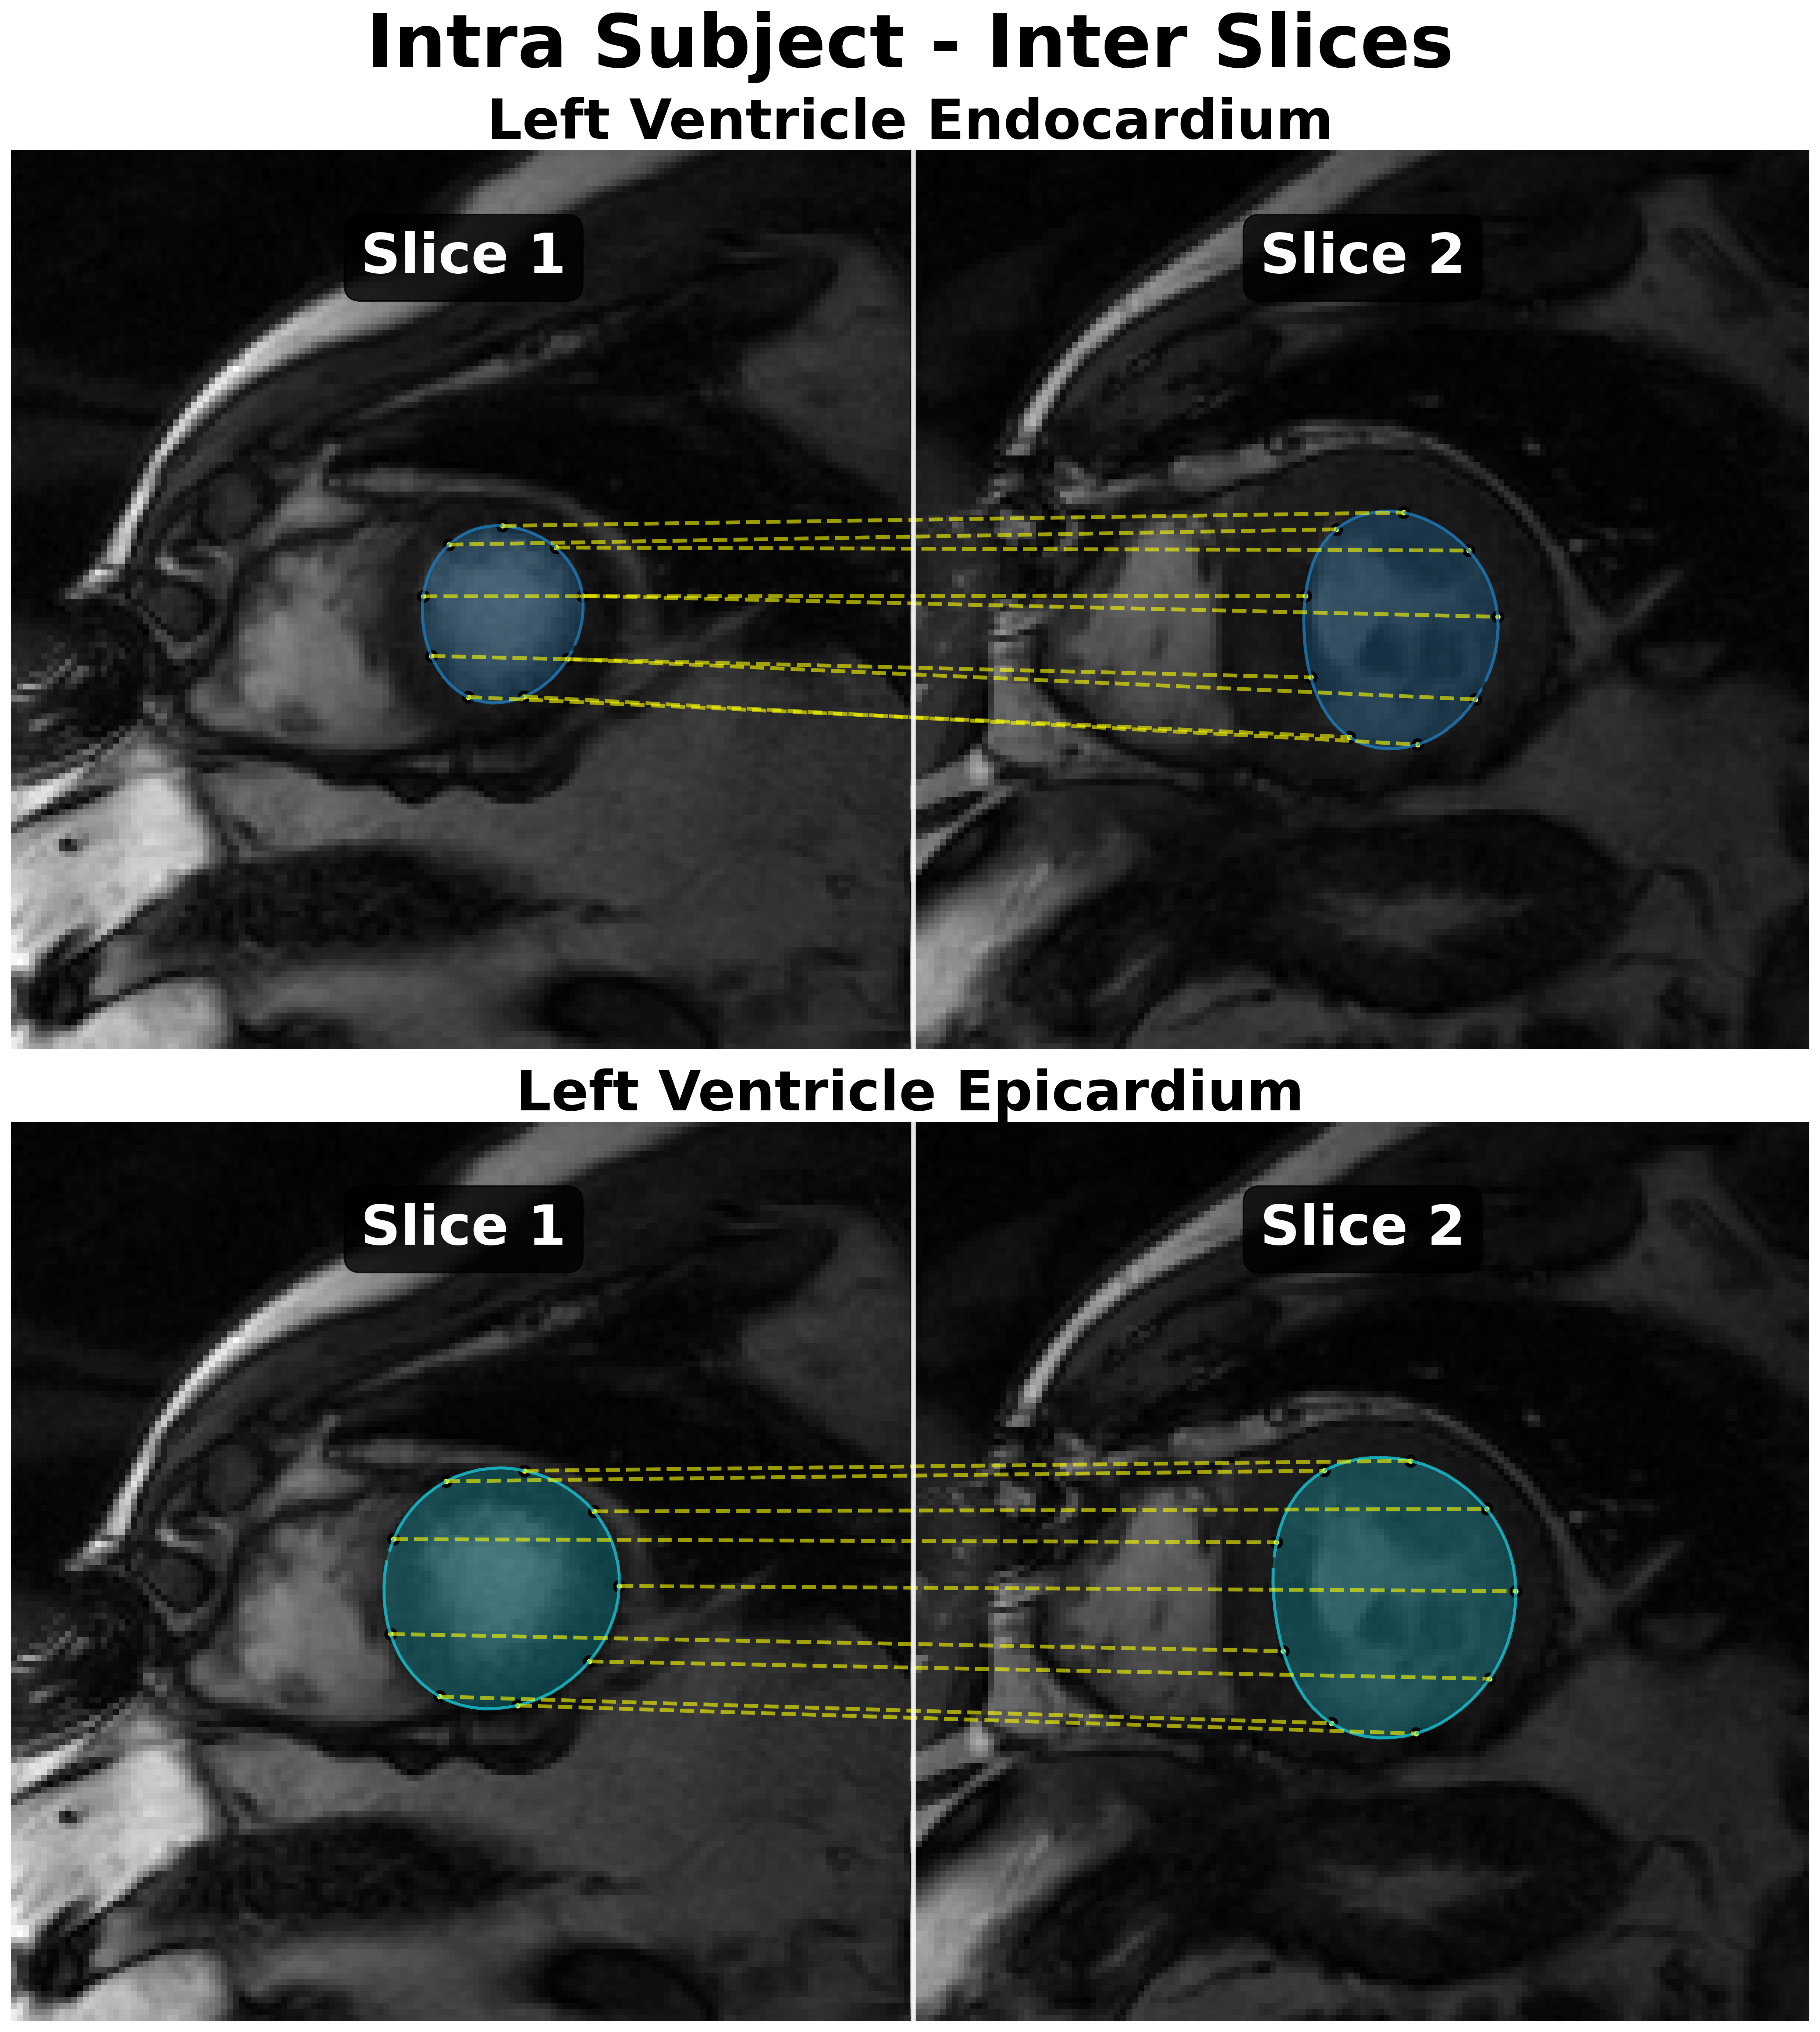

In [26]:
colors = plt.cm.get_cmap('tab10', len(organ_order))
organ_id = np.load("%s/Naive/adj_full_organ_id.npy" % DATASET)[:,0]
organ_order = np.unique(organ_id)

# Create subplot in 4x2 grid
plt.figure(figsize=(18, 18), dpi=300)

# replace keys with complete names
config['organ_names'] = ['Left Ventricle Endocardium', 'Left Ventricle Epicardium']

k = 0
for organ in np.unique(organ_id):  
    plt.subplot(len(np.unique(organ_id)),1,k+1)
    # Show both images side by side
    # Zoom in on the organ region
    img_1_zoom = img1[50:200, 50:200]
    img_2_zoom = img2[50:200, 50:200]
    combined_img = np.concatenate([img_1_zoom, img_2_zoom], axis=1)

    #combined_img = np.concatenate([img1, img2], axis=1)
    plt.imshow(combined_img, cmap='gray')

    # Process all organs in this group together to avoid overlap
    all_landmarks_1 = []
    all_landmarks_2 = []
    organ_labels = []

    print(f"Processing organ {k+1}/{len(np.unique(organ_id))}: {config['organ_names'][k]}")          
    idx_organ = organ_id == organ
       
    key = config["organ_names"][k]
        
    # Collect all landmarks for this group
    x1, y1 = output1[idx_organ, 0] - 50, output1[idx_organ, 1] - 50
    x2, y2 = output2[idx_organ, 0] + 100, output2[idx_organ, 1] - 50
    
    all_landmarks_1.extend(list(zip(x1, y1)))
    all_landmarks_2.extend(list(zip(x2, y2)))
    
    # Draw contours for each organ
    plt.plot(x1, y1, color=colors(k), linewidth=2, alpha=0.8, label=key)
    plt.plot(x2, y2, color=colors(k), linewidth=2, alpha=0.8)
    
    # Fill area under the points
    plt.fill(x1, y1, color=colors(k), alpha=0.3)  # Fill area under the points
    plt.fill(x2, y2, color=colors(k), alpha=0.3)
    
    k += 1
    
    # Draw correspondence lines - sample points to avoid clutter
    n_total = len(all_landmarks_1)
    if n_total > 20:  # If too many landmarks, sample them
        indices = np.linspace(0, n_total-1, 10, dtype=int)[:-1]  # Show ~15 correspondences
    else:
        indices = range(n_total)

    for idx in indices:
        x1, y1 = all_landmarks_1[(idx + 6) % n_total]
        x2, y2 = all_landmarks_2[(idx + 6) % n_total]
        plt.plot([x1, x2], [y1, y2], 'yellow', alpha=0.6, linewidth=2.5, linestyle='--')
        
        # Add small markers
        plt.scatter([x1, x2], [y1, y2], color='yellow', s=35, edgecolor='black', linewidth=2.5)

    plt.title(f"{key}", fontsize=36, weight='bold')
    plt.axis('off')

    # Add subject divider and labels
    plt.axvline(x=img_1_zoom.shape[1], color='white', linewidth=3, alpha=0.9)
    plt.text(img_1_zoom.shape[1]//2, 20, 'Slice 1', ha='center', fontsize=36, 
                color='white', weight='bold', bbox=dict(boxstyle="round", facecolor='black', alpha=0.8))
    plt.text(img_1_zoom.shape[1] + img_2_zoom.shape[1]//2, 20, 'Slice 2', ha='center', fontsize=36, 
                color='white', weight='bold', bbox=dict(boxstyle="round", facecolor='black', alpha=0.8))

plt.suptitle('Intra Subject - Inter Slices', fontsize=48, weight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig(f"{DATASET}/sunnybrook_intra_subject.png", dpi=300, bbox_inches='tight')
plt.show()

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import random
from utils.image_processing import draw_lines, draw_organ

# Load organ IDs
organ_id = np.load("%s/Naive/adj_full_organ_id.npy" % DATASET)[:,0]
organ_order = np.unique(organ_id)

# Enable interactive mode
plt.ion()

# Number of sample pairs to display
num_samples = 1

# Randomly select indices from the validation set
random_indices = random.sample(range(len(val_dataset)), num_samples * 2)
# Split indices into two groups for side-by-side comparison
comparison_pairs = [(random_indices[i], random_indices[i+num_samples]) for i in range(num_samples)]

comparison_pairs = [[18, 47]]

# For each randomly selected pair of samples
for j, (idx1, idx2) in enumerate(comparison_pairs):
    # Get the two samples from validation set
    sample1 = val_dataset[idx1]
    image1, landmarks1, raster1 = sample1['image'], sample1['landmarks'], sample1['raster']
    
    sample2 = val_dataset[idx2]
    image2, landmarks2, raster2 = sample2['image'], sample2['landmarks'], sample2['raster']
    
    # Run model inference
    out1 = model(image1.unsqueeze(0).to(config['device']))[0]
    out1 = out1 * config['inputsize']
    output1 = out1.squeeze(0).cpu().detach().numpy()
    
    out2 = model(image2.unsqueeze(0).to(config['device']))[0]
    out2 = out2 * config['inputsize']
    output2 = out2.squeeze(0).cpu().detach().numpy()
    
    # Convert tensors to numpy arrays
    img1 = image1.squeeze(0).cpu().detach().numpy()
    img2 = image2.squeeze(0).cpu().detach().numpy()

Processing organ 1/2: Left Ventricle Endocardium
Processing organ 2/2: Left Ventricle Epicardium


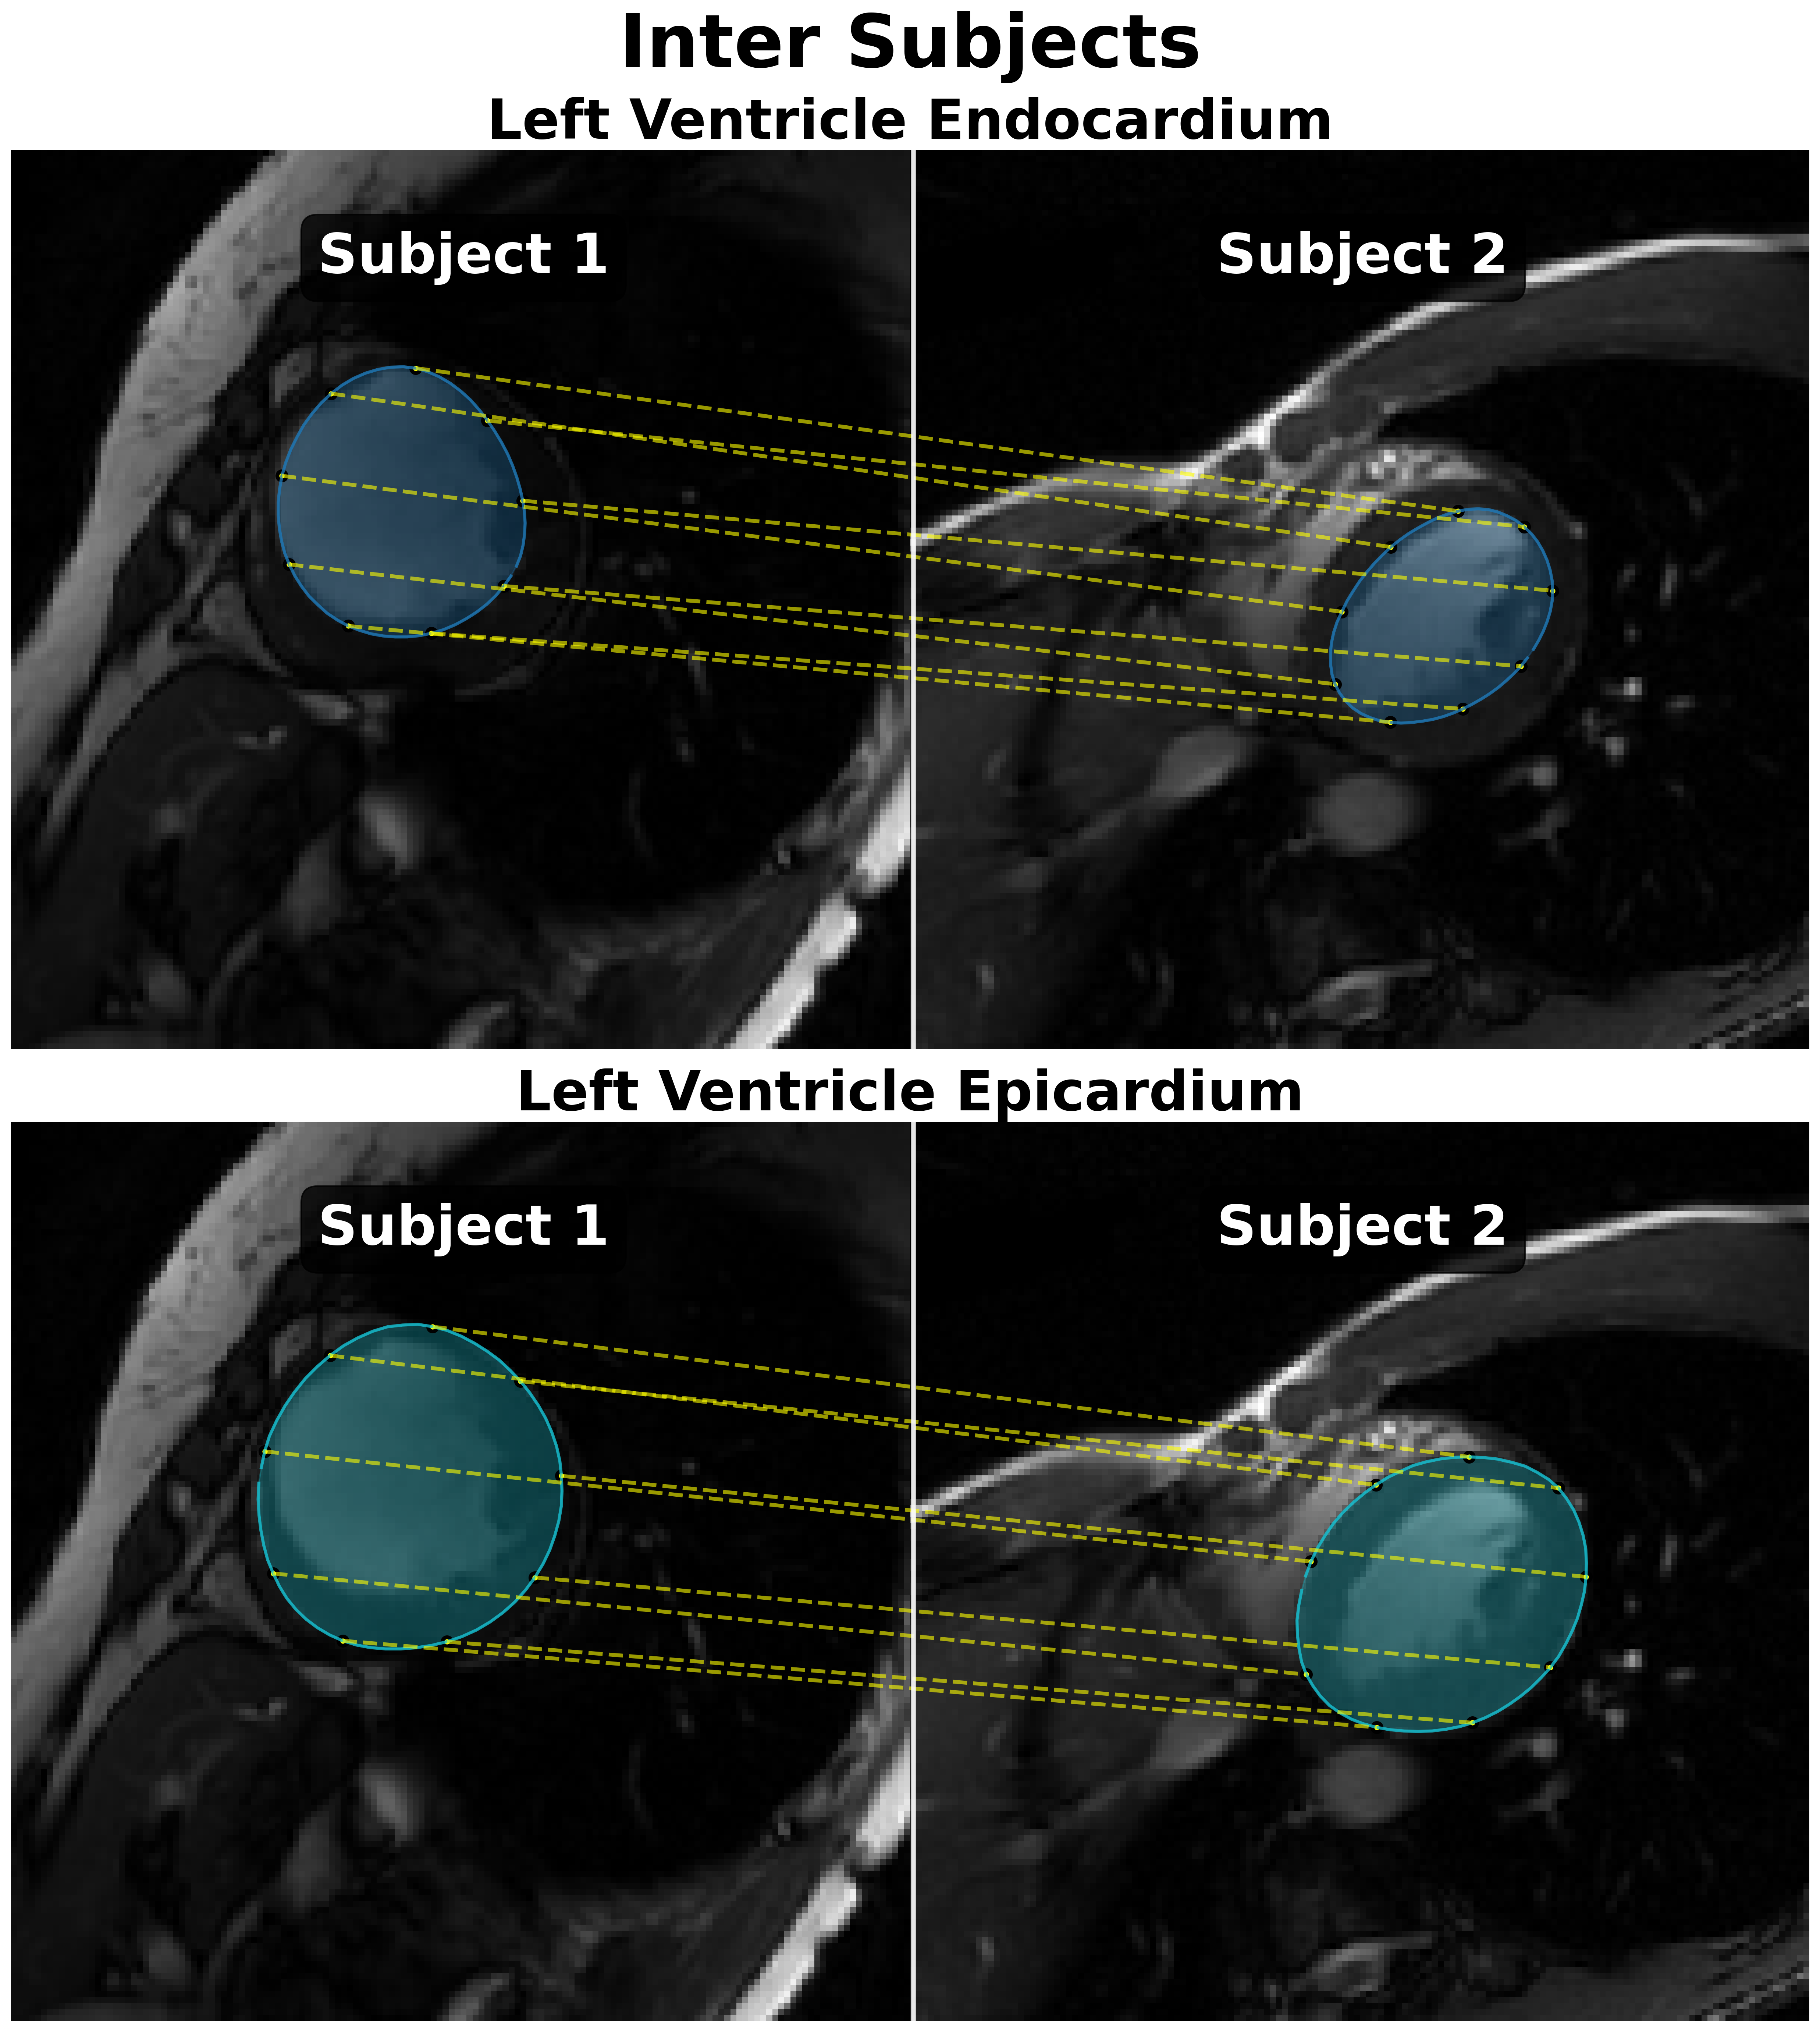

In [28]:
colors = plt.cm.get_cmap('tab10', len(organ_order))
organ_id = np.load("%s/Naive/adj_full_organ_id.npy" % DATASET)[:,0]
organ_order = np.unique(organ_id)

# Create subplot in 4x2 grid
plt.figure(figsize=(18, 18), dpi=300)

k = 0
for organ in np.unique(organ_id):  
    plt.subplot(len(np.unique(organ_id)),1,k+1)
    # Show both images side by side
    # Zoom in on the organ region
    img_1_zoom = img1[50:200, 50:200]
    img_2_zoom = img2[50:200, 50:200]
    combined_img = np.concatenate([img_1_zoom, img_2_zoom], axis=1)

    #combined_img = np.concatenate([img1, img2], axis=1)
    plt.imshow(combined_img, cmap='gray')

    # Process all organs in this group together to avoid overlap
    all_landmarks_1 = []
    all_landmarks_2 = []
    organ_labels = []

    print(f"Processing organ {k+1}/{len(np.unique(organ_id))}: {config['organ_names'][k]}")          
    idx_organ = organ_id == organ
       
    key = config["organ_names"][k]
        
    # Collect all landmarks for this group
    x1, y1 = output1[idx_organ, 0] - 50, output1[idx_organ, 1] - 50
    x2, y2 = output2[idx_organ, 0] + 100, output2[idx_organ, 1] - 50
    
    all_landmarks_1.extend(list(zip(x1, y1)))
    all_landmarks_2.extend(list(zip(x2, y2)))
    
    # Draw contours for each organ
    plt.plot(x1, y1, color=colors(k), linewidth=2, alpha=0.8, label=key)
    plt.plot(x2, y2, color=colors(k), linewidth=2, alpha=0.8)
    
    # Fill area under the points
    plt.fill(x1, y1, color=colors(k), alpha=0.3)  # Fill area under the points
    plt.fill(x2, y2, color=colors(k), alpha=0.3)
    
    k += 1
    
    # Draw correspondence lines - sample points to avoid clutter
    n_total = len(all_landmarks_1)
    if n_total > 20:  # If too many landmarks, sample them
        indices = np.linspace(0, n_total-1, 10, dtype=int)[:-1]  # Show ~15 correspondences
    else:
        indices = range(n_total)

    for idx in indices:
        x1, y1 = all_landmarks_1[(idx + 6) % n_total]
        x2, y2 = all_landmarks_2[(idx + 6) % n_total]
        plt.plot([x1, x2], [y1, y2], 'yellow', alpha=0.6, linewidth=2.5, linestyle='--')
        
        # Add small markers
        plt.scatter([x1, x2], [y1, y2], color='yellow', s=35, edgecolor='black', linewidth=2.5)

    plt.title(f"{key}", fontsize=36, weight='bold')
    plt.axis('off')

    # Add subject divider and labels
    plt.axvline(x=img_1_zoom.shape[1], color='white', linewidth=3, alpha=0.9)
    plt.text(img_1_zoom.shape[1]//2, 20, 'Subject 1', ha='center', fontsize=36, 
                color='white', weight='bold', bbox=dict(boxstyle="round", facecolor='black', alpha=0.8))
    plt.text(img_1_zoom.shape[1] + img_2_zoom.shape[1]//2, 20, 'Subject 2', ha='center', fontsize=36, 
                color='white', weight='bold', bbox=dict(boxstyle="round", facecolor='black', alpha=0.8))

plt.suptitle('Inter Subjects', fontsize=48, weight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig(f"{DATASET}/sunnybrook_inter_subject.png", dpi=300,bbox_inches='tight')
plt.show()

In [29]:
import cv2 
# open both intra and inter subject images
intra_img = cv2.imread(f"{DATASET}/sunnybrook_intra_subject.png")
inter_img = cv2.imread(f"{DATASET}/sunnybrook_inter_subject.png")

# paste them side by side
combined_img = np.concatenate([intra_img, inter_img], axis=1)
cv2.imwrite(f"{DATASET}/sunnybrook_combined.png", combined_img)

True